In [172]:
from diffrax import diffeqsolve, ODETerm, SaveAt, Tsit5
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import random


# Make a graph Laplacian

Making a $RxR$ graph laplacian from a dense graph with binary edges. In this case $R = 10$

In [173]:
A = jnp.ones((10,10)) - jnp.diag(jnp.ones((10)))
L = jnp.diag(jnp.sum(A, 1)) - A

# Define the ODE 

The ODE system is given for a set of $i = 1 ... R$ variables $u_i$ and represents FKPP like dynamics. The transport and production can be weighted such that nodes and edges have distinct weights. The ODE is

$$
\frac{du_i}{dt} = - \rho 
\sum_i^R\mathcal{W}_{ij} u_j + \alpha p_i u_i ( 1  - u_i )
$$

where $\mathbf{W} \in \mathbb{R}^{R \times R}$ is a weighted Laplacian matrix and $\mathbf{p} \in \mathbb{R}^{R}$ is a weighted production vector. 

$\mathbf{W}$ is defined as $\mathbf{W} = \mathbf{L}(\mathbf{I} + \text{diag}(\mathbf{F_t}\mathbf{s_t}))$, where $\mathbf{F_t} \in \mathbb{R}^{R \times N}$ is a matrix of $N$ feature vectors for transport and $\mathbf{s_t} \in \mathbb{N}^N$ is a selection vector for transport.

$\mathbf{p}$ is defined as $\gamma \mathbf{F_p}\mathbf{s_p}$ where $\mathbf{F_p} \in \mathbb{R}^{R \times N}$ is a matrix of $N$ feature vectors for production and $\mathbf{s_p} \in \mathbb{N}^N$ is a selection vector for production.

In [ ]:
production_weight_matrix = jnp.reshape(jnp.arange(1, 201), (10, 20)) / 200 # 10 x 20 weight matrix for productino 
production_weight_selection = jnp.array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]) # selection vector for production weights 

transport_weight_matrix = jnp.outer(jnp.arange(1, 11), jnp.arange(1,11)) / 100 # 10 x 10 weight matrix for transport
transport_weight_selection = jnp.array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0]) # selectinon matrix for transport 

# define the ODE 
def NetworkFKPP(t, u, args):
    transport_rate, production_rate = args # params
    wL = jnp.dot(L, jnp.eye(10) + jnp.diag(transport_weight_matrix @ transport_weight_selection)) # weighted laplacian
    p = jnp.dot(production_weight_matrix, production_weight_selection) # production weights
    du = -transport_rate * jnp.dot(wL, u) + production_rate * p * u * ( 1 - u ) # vector field
    return du


term = ODETerm(NetworkFKPP)
solver = Tsit5()
t0 = 0
t1 = 30
dt0 = 0.1
u0 = random.uniform(random.key(0), shape=(10,))
args = (0.1, 1.0)
saveat = SaveAt(ts=jnp.linspace(t0, t1, 100))
sol = diffeqsolve(term, solver, t0, t1, dt0, u0, args=args, saveat=saveat)

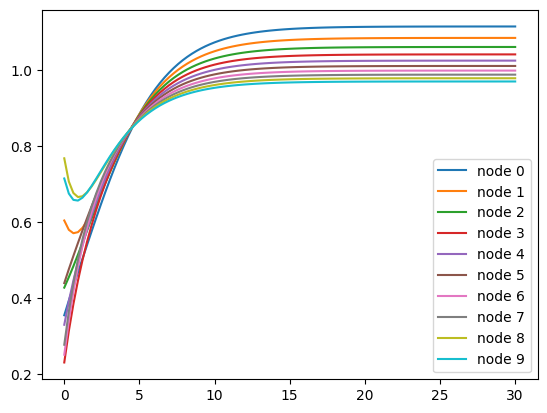

In [ ]:
for i in range(0,10,1):
    plt.plot(sol.ts, sol.ys[:,i], label=f"node {i}")

plt.legend()
plt.show()